# 06 — Seniority & Experience

Seniority distribution and experience year requirements across the market. Breaks down how the market is segmented by career level, what experience is expected per job family, and where entry-level roles are geographically concentrated.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family, salary_df

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 19,148 rows × 29 columns
After excluding future-dated rows: 19,098 rows


In [2]:
import pandas as pd
from analysis.charts import horizontal_bar, box_plot

## Data Quality & Coverage

In [3]:
total = len(df)
seniority_known = df["seniority_from_title"].notna().sum()
exp_known = df["experience_years"].notna().sum()
salary_known = df[df["salary_min"].notna() & df["salary_max"].notna()].shape[0]

print(f"Total rows: {total:,}")
print(f"Seniority available:       {seniority_known:,} / {total:,}  ({seniority_known/total*100:.1f}%)")
print(f"Experience years available: {exp_known:,} / {total:,}  ({exp_known/total*100:.1f}%)")
print(f"Salary data available:     {salary_known:,} / {total:,}  ({salary_known/total*100:.1f}%)")
print()
print("Seniority breakdown:")
print(df["seniority_from_title"].value_counts(dropna=False).to_string())

Total rows: 19,098
Seniority available:       5,917 / 19,098  (31.0%)
Experience years available: 5,352 / 19,098  (28.0%)
Salary data available:     403 / 19,098  (2.1%)

Seniority breakdown:
seniority_from_title
NaN         13181
Senior       4210
Lead          893
Junior        747
Director       42
C-Level        25


Seniority is derived from the job title and is available for most postings. Experience years are less frequently specified explicitly. Salary data is sparse (~2% of rows), so salary-by-seniority analysis should be interpreted with caution.

## Seniority Distribution

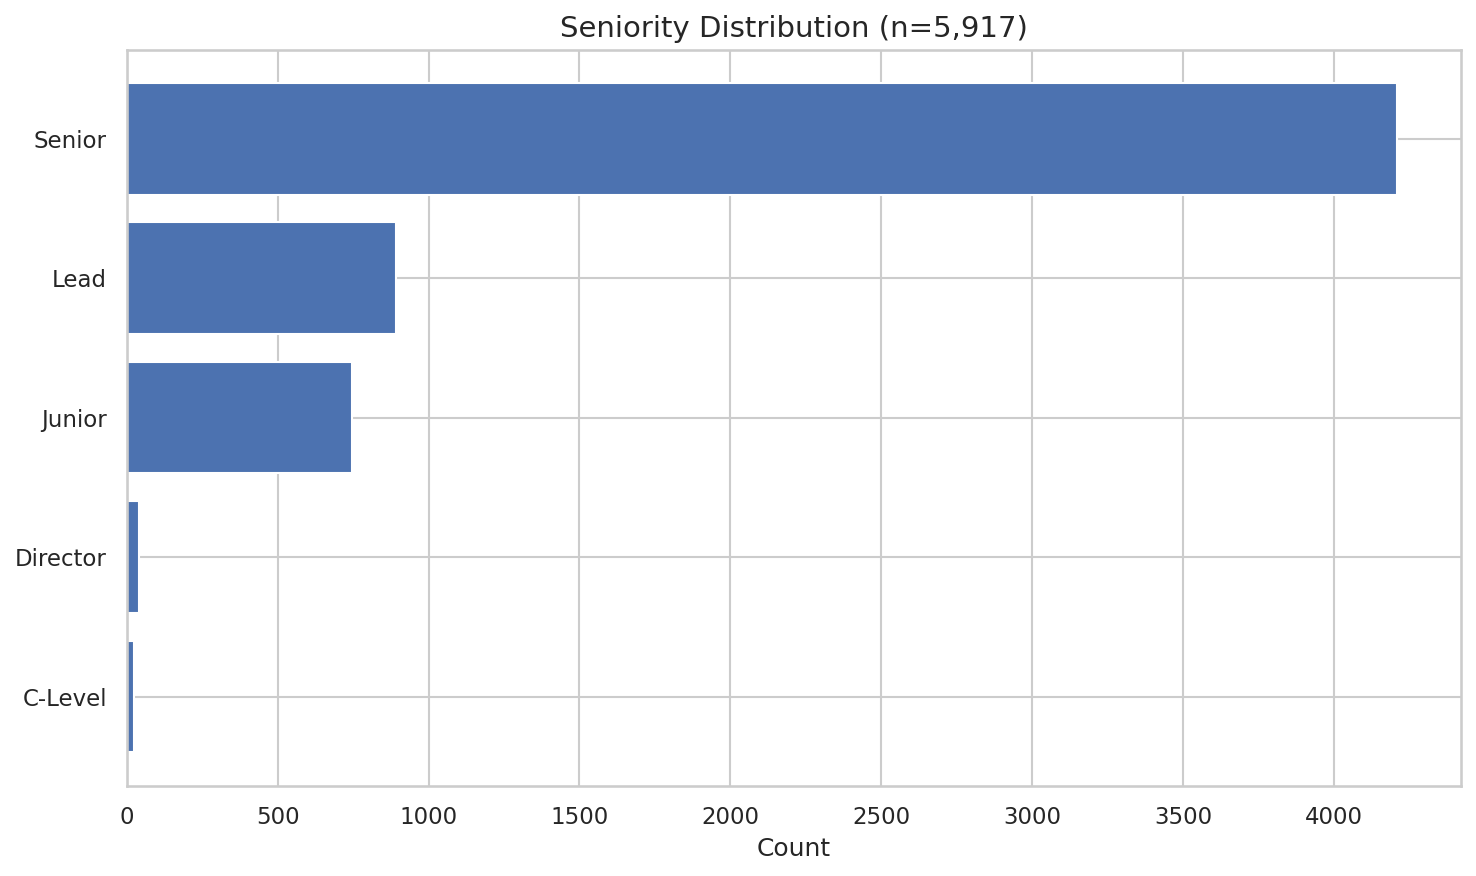

In [4]:
n_seniority = df["seniority_from_title"].notna().sum()

horizontal_bar(
    df["seniority_from_title"],
    f"Seniority Distribution (n={n_seniority:,})",
    save_as="06_seniority.png",
)

**Takeaway:** Mid-level roles dominate the market, which is typical for mature IT markets. Senior roles are the second-largest category, reflecting strong demand for experienced professionals. Junior and Lead positions are comparatively rarer, suggesting a competitive landscape for entry-level candidates and a relatively flat organizational structure at many companies.

## Experience Years by Job Family

Rows with valid experience data: 5,208

Sample sizes per job family:
  System Administrator: n=648
  SAP Consultant: n=551
  Fullstack Developer: n=531
  Software Developer: n=425
  Solution Architect: n=411
  Cloud Engineer: n=258
  Data Engineer: n=230
  Backend Developer: n=224
  DevOps Engineer: n=217
  IT Security Engineer: n=161
  Frontend Developer: n=143
  Software Architect: n=130
  Embedded Developer: n=127
  AI Engineer: n=122
  IT Consultant: n=119
  IT Support / Helpdesk: n=111
  Platform Engineer: n=90
  QA Engineer: n=86
  Data Analyst: n=75
  Data Scientist: n=75
  Technical Lead: n=66
  Business Analyst: n=58
  Business Intelligence Developer: n=52
  Product Manager: n=42
  Network Engineer: n=38
  ML Engineer: n=37
  Mobile Developer: n=31
  Engineering Manager: n=26
  ERP Consultant: n=23
  Working Student: n=20
  MLOps Engineer: n=15
  Site Reliability Engineer: n=15
  Database Administrator: n=14
  Project Manager: n=13
  Intern: n=9
  UI/UX Designer: n=7
  Scrum M

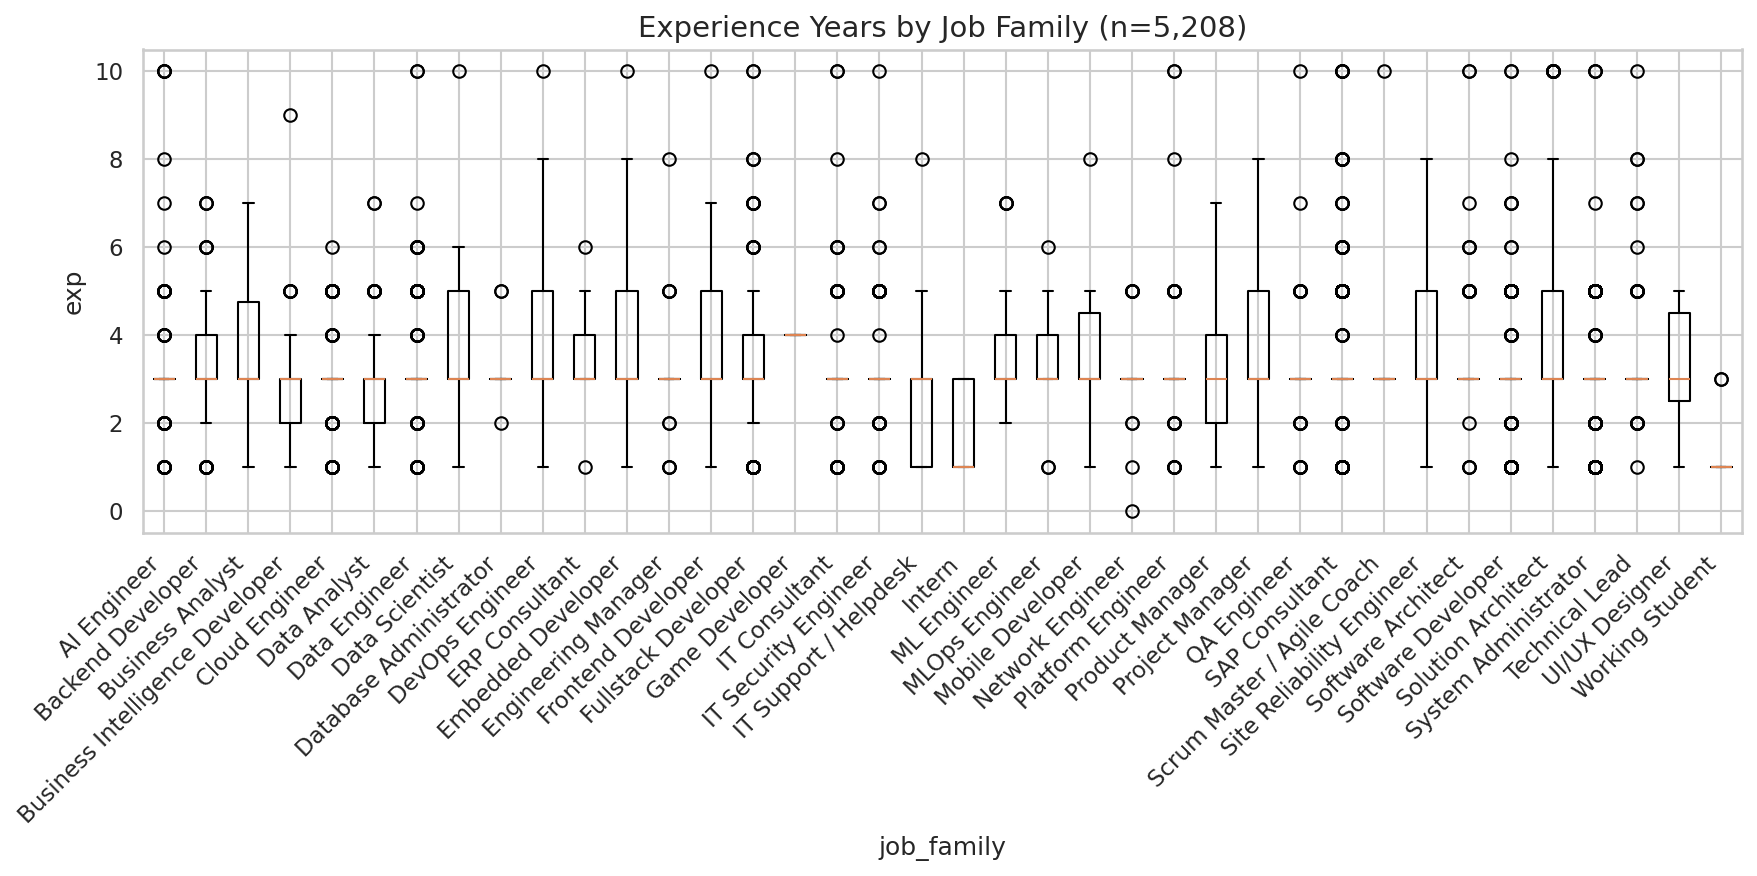

In [5]:
df_fam = exclude_other_family(df)
exp_df = df_fam[df_fam["experience_years"].notna()].copy()
exp_df["exp"] = pd.to_numeric(exp_df["experience_years"], errors="coerce")
exp_df = exp_df[exp_df["exp"].notna()]
exp_df["exp"] = exp_df["exp"].astype(int)

# Print sample sizes per family
print(f"Rows with valid experience data: {len(exp_df):,}")
print()
family_counts = exp_df["job_family"].value_counts()
print("Sample sizes per job family:")
for fam, n in family_counts.items():
    print(f"  {fam}: n={n:,}")
print()

box_plot(
    exp_df,
    "job_family",
    "exp",
    f"Experience Years by Job Family (n={len(exp_df):,})",
    save_as="06_exp_family.png",
)

**Takeaway:** Experience requirements vary significantly by role. Architecture and Lead-level roles naturally demand the most years, while Working Student and Junior-targeted families have the lowest bars. Interestingly, some families show wide interquartile ranges, indicating that employers within the same domain can have very different expectations for candidate experience.

## Entry-level (Junior) Density by City

Total junior postings with city data: 730



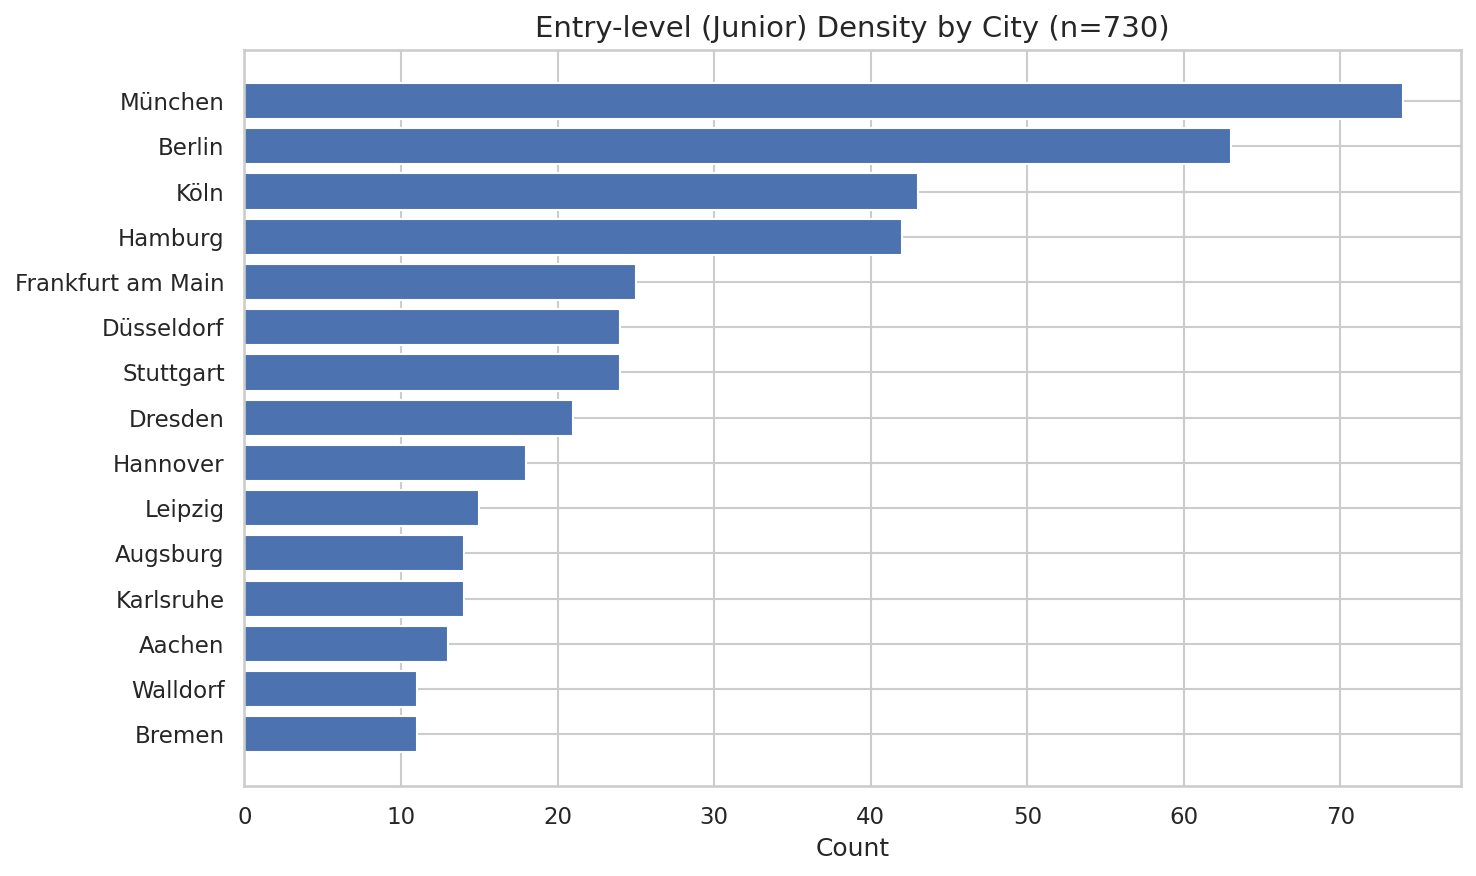

In [6]:
junior_df = df[
    (df["seniority_from_title"].str.lower() == "junior") & (df["city"].notna())
]
n_junior = len(junior_df)

print(f"Total junior postings with city data: {n_junior:,}")
print()

horizontal_bar(
    junior_df["city"],
    f"Entry-level (Junior) Density by City (n={n_junior:,})",
    top_n=15,
    save_as="06_junior_cities.png",
)

**Takeaway:** Entry-level IT jobs are concentrated in the same major hubs as the overall market (Berlin, Munich, Hamburg), but their relative shares can differ. Job seekers starting their career may find the best odds in the largest cities, where a critical mass of companies actively hires juniors.

## Seniority vs Salary

Rows with salary data: 403 (2.1% of total)

Salary-known rows per seniority level:
  (unspecified): n=272
  Senior: n=96
  Lead: n=24
  Junior: n=10
  Director: n=1

⚠  Salary data is sparse. Interpret these distributions with caution.



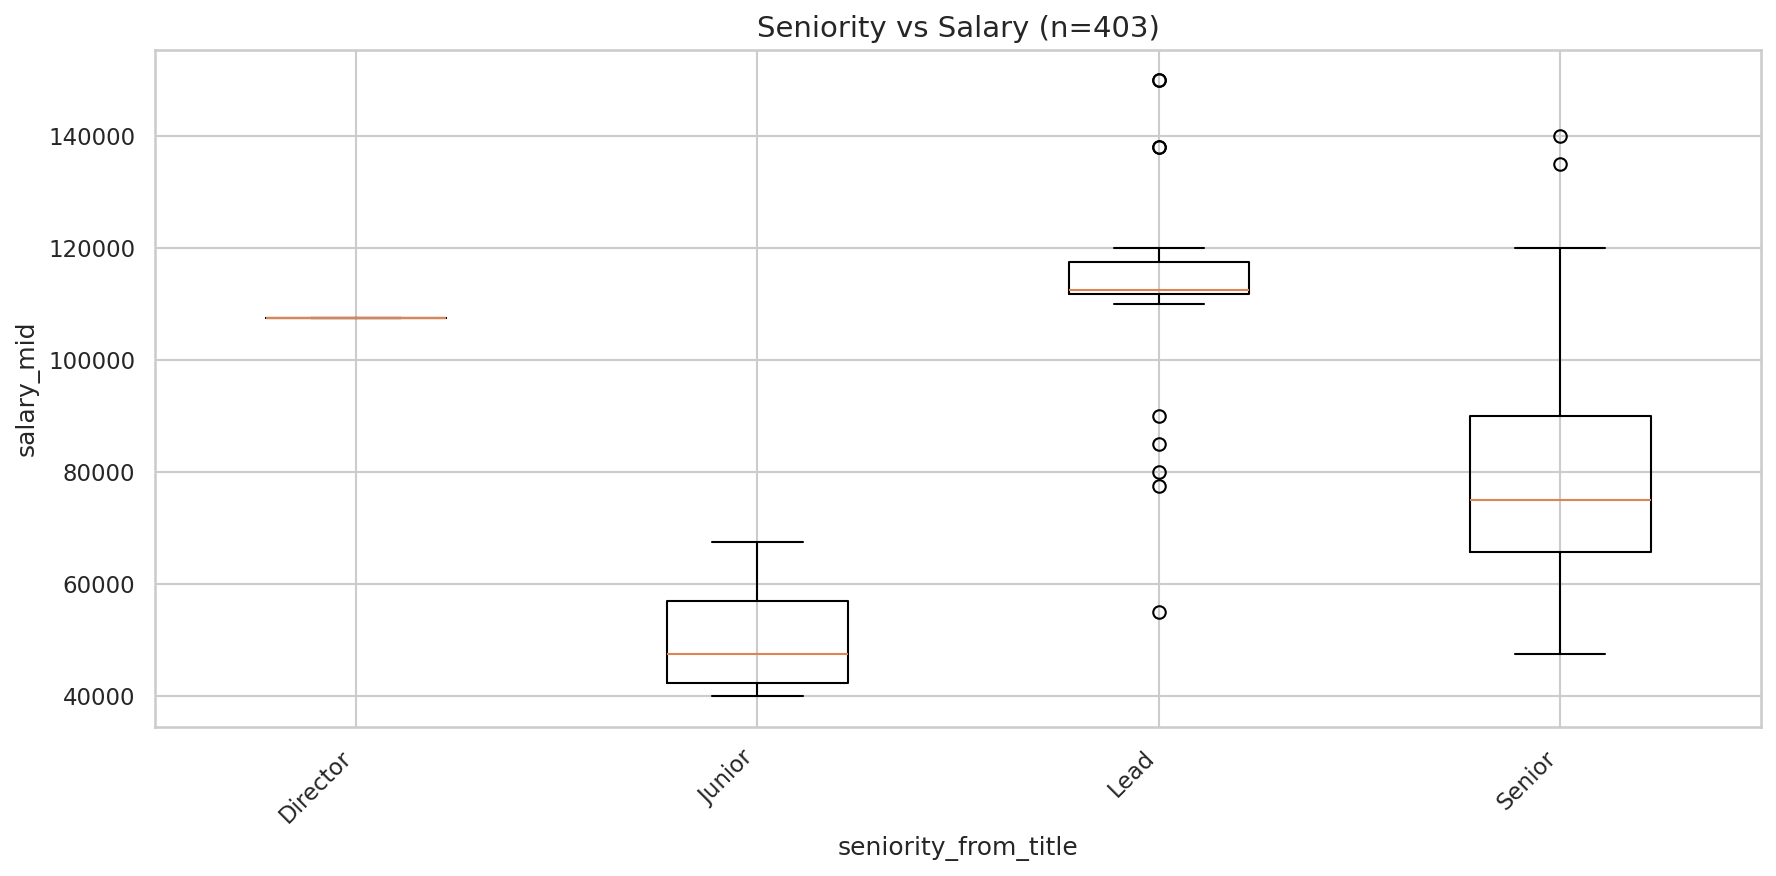

In [7]:
sdf = salary_df(df)
n_salary = len(sdf)

# Print salary coverage per seniority level
print(f"Rows with salary data: {n_salary:,} ({n_salary/len(df)*100:.1f}% of total)")
print()
seniority_salary_counts = sdf["seniority_from_title"].value_counts(dropna=False)
print("Salary-known rows per seniority level:")
for level, n in seniority_salary_counts.items():
    label = level if pd.notna(level) else "(unspecified)"
    print(f"  {label}: n={n:,}")
print()
print("⚠  Salary data is sparse. Interpret these distributions with caution.")
print()

box_plot(
    sdf,
    "seniority_from_title",
    "salary_mid",
    f"Seniority vs Salary (n={n_salary:,})",
    save_as="06_seniority_salary.png",
)

**Takeaway:** Despite the limited salary sample, a clear progression is visible: Lead and Senior roles command meaningfully higher salaries than Mid and Junior positions. The spread within each level is wide, reflecting differences in company size, location, and specialization. Given the small sample (~2% of postings include salary), these figures should be treated as directional rather than definitive.